<a href="https://colab.research.google.com/github/manyasachdeva27/MACHINE-LEARNING/blob/main/Outlier_detection_using_Percentile_method_(Winsorisation_method).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv('/content/weight-height.csv')

In [24]:
df.shape

(10000, 3)

In [8]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [10]:
df.shape

(10000, 3)

In [12]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


In [13]:
df['Weight'].describe()

,Weight
count,10000.000000
mean,161.440357
std,32.108439
min,64.700127
25%,135.818051
50%,161.212928
75%,187.169525
max,269.989699


/tmp/ipython-input-220/3635928557.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'],hist=False)


<Axes: xlabel='Height', ylabel='Density'>

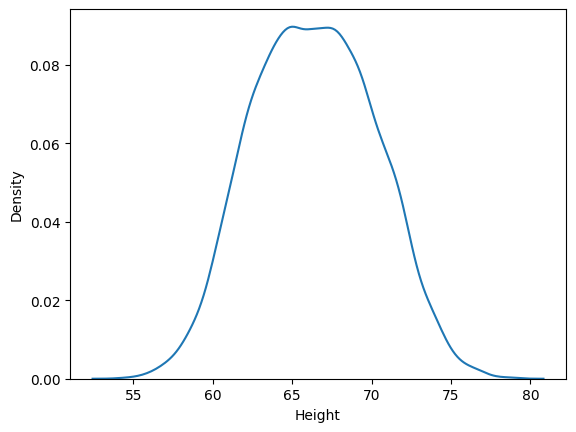

In [16]:
sns.distplot(df['Height'],hist=False)

/tmp/ipython-input-220/3390808647.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'],hist=False)


<Axes: xlabel='Weight', ylabel='Density'>

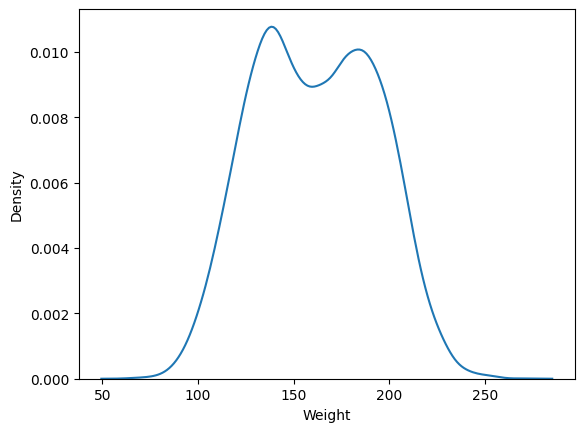

In [17]:
sns.distplot(df['Weight'],hist=False)

<Axes: ylabel='Height'>

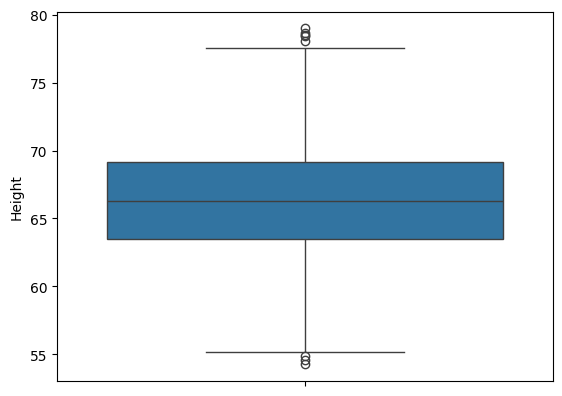

In [18]:
sns.boxplot(df['Height'])

<Axes: ylabel='Weight'>

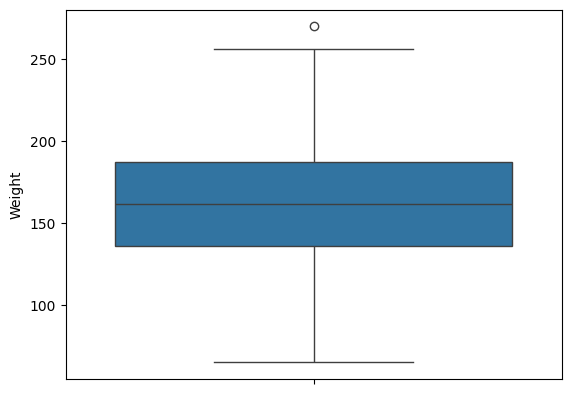

In [19]:
sns.boxplot(df['Weight'])

In [20]:
upper_threshold=df['Height'].quantile(0.99)
upper_threshold

np.float64(74.7857900583366)

In [21]:
lower_threshold=df['Height'].quantile(0.01)
lower_threshold

np.float64(58.13441158671655)

In [27]:
#detect outliers
df[(df['Height']>=upper_threshold )| (df['Height']<=lower_threshold)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [30]:
#trimming

new_df_height=df[(df['Height']<=upper_threshold )& (df['Height']>=lower_threshold)]
new_df_height

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [32]:
new_df_height['Height'].describe()

,Height
count,9800.000000
mean,66.364366
std,3.645075
min,58.134496
25%,63.577162
50%,66.318070
75%,69.119896
max,74.785714


/tmp/ipython-input-220/3491607727.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_height['Height'],hist=False)


<Axes: xlabel='Height', ylabel='Density'>

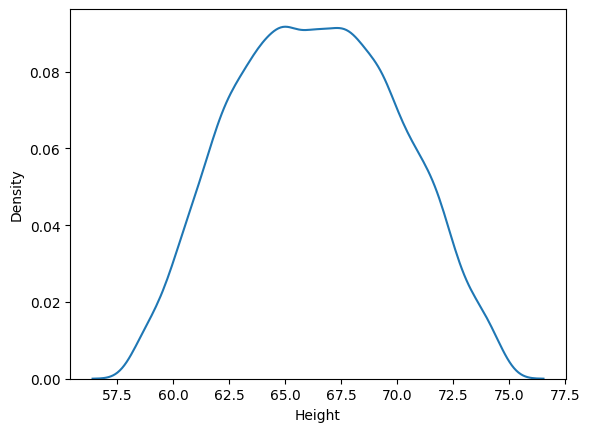

In [33]:
sns.distplot(new_df_height['Height'],hist=False)

<Axes: ylabel='Height'>

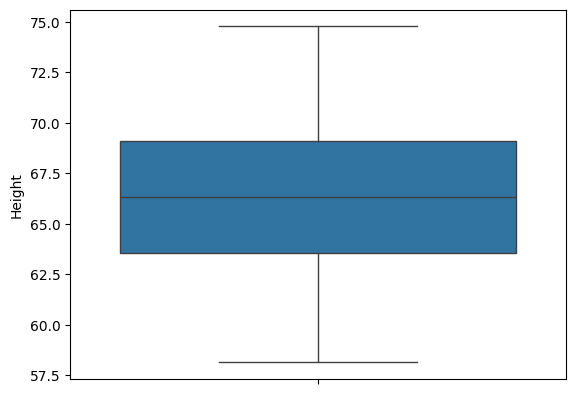

In [34]:
sns.boxplot(new_df_height['Height'])

In [36]:
#Capping (Winsorisation)

df['Height']=np.where(df['Height']>=upper_threshold,upper_threshold,np.where(df['Height']<=lower_threshold,lower_threshold,df['Height']))
df


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [37]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


/tmp/ipython-input-220/3635928557.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'],hist=False)


<Axes: xlabel='Height', ylabel='Density'>

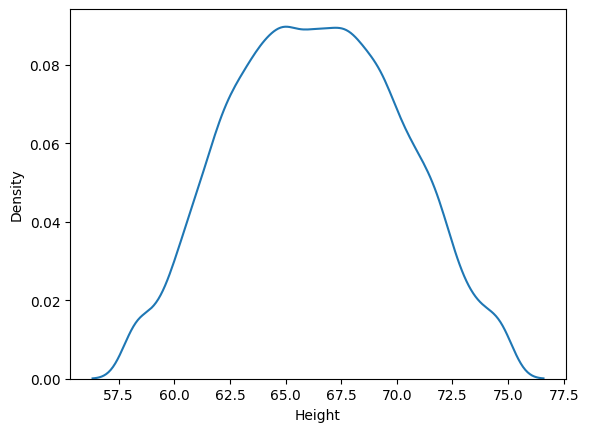

In [38]:
sns.distplot(df['Height'],hist=False)

<Axes: ylabel='Height'>

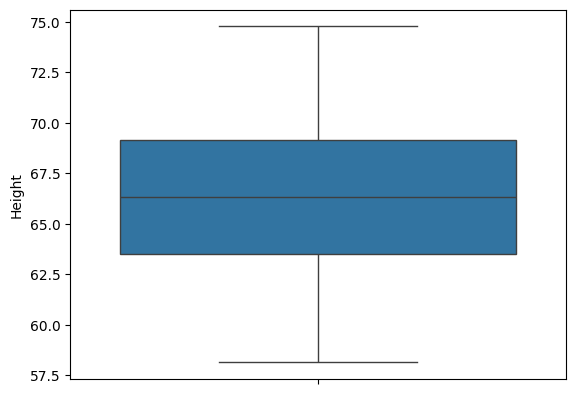

In [39]:
sns.boxplot(df['Height'])